<a href="https://colab.research.google.com/github/mrivassnj-svg/HCC_ITAI_1371_SPR26/blob/main/Module_05_Lab_Data_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 05 Lab - Data Preparation**Objective:** To learn and apply the most common data preparation techniques. Raw data is rarely ready for a machine learning model. This process, also called preprocessing, is one of the most critical steps in the entire ML workflow.**In this lab, you will write more of the code.** Read the explanations and then complete the tasks in the code cells.

## Part 1: Setup and Initial LookWe will continue using the Titanic dataset because it has the exact problems we need to solve: missing values and non-numeric data.

In [2]:
import pandas as pd
import numpy as np
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
# Let's look at the missing values
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

--- Missing Values Before Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Part 2: Handling Missing Values (Imputation)**Concept:** Most machine learning models cannot handle missing values (`NaN`). We must deal with them. Dropping the rows is an option, but you lose data. A better way is **imputation**, which means filling in the missing values with a calculated guess.Common imputation strategies:*   **Mean:** Fill with the average value. Good for normally distributed data.*   **Median:** Fill with the middle value. Better for skewed data or data with outliers (like `Fare`).*   **Mode:** Fill with the most frequent value. Used for categorical data.

### Task 1: Impute the 'Age' ColumnThe 'Age' column is missing many values. Since age can be skewed (e.g., by a few very old passengers), using the **median** is a robust choice.**Your Task:** Calculate the median of the 'Age' column and use the `.fillna()` method to replace the missing values.

In [9]:
# Step 1: Find the middle (median) age
age_median = df["Age"].median()

# Step 2: Replace missing ages with that value
df["Age"] = df["Age"].fillna(age_median)

# Step 3: Check that no missing values remain
print("Remaining missing values in Age column:")
print(df["Age"].isna().sum())

Remaining missing values in Age column:
0


## Part 3: Encoding Categorical Features**Concept:** Machine learning models are mathematical, so they need numbers, not text. We need to convert categorical columns (like 'Sex' and 'Embarked') into a numerical format. The most common method is **One-Hot Encoding**.One-Hot Encoding takes a column with `N` categories and turns it into `N` new columns, each with a `1` or `0`. For example, the 'Sex' column (`male`, `female`) becomes two new columns: `Sex_male` and `Sex_female`.Pandas has a convenient function called `pd.get_dummies()` that does this for us.

### Task 2: One-Hot Encode Categorical Columns**Your Task:** Use `pd.get_dummies()` to encode the 'Sex' and 'Embarked' columns. Make sure to drop the original columns after encoding.

In [13]:
# Convert text categories into numeric indicator columns
# drop_first=True avoids creating duplicate information
encoded_df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

# Show the updated dataset structure
print(encoded_df.head())



   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500   NaN      True       False        True  
1          PC 17599  71.2833   C85     False       False       False  
2  STON/O2. 3101282   7.9250   NaN     False       False        True  
3            113803  53.1000  C123     Fal

## Part 4: Feature Scaling**Concept:** Many models are sensitive to the scale of the features. For example, `Age` (from 0-80) and `Fare` (from 0-512) are on very different scales. This can cause the model to incorrectly believe that `Fare` is a more important feature simply because its values are larger.**Feature Scaling** solves this by putting all features on a similar scale. A common method is **Standardization** (`StandardScaler` in scikit-learn), which rescales the data to have a mean of 0 and a standard deviation of 1.**Important:** You only scale your numerical features, not your target variable or your newly encoded categorical columns.

### Task 3: Scale the 'Age' and 'Fare' Columns**Your Task:** Use `StandardScaler` from `sklearn.preprocessing` to scale the 'Age' and 'Fare' columns.

In [14]:
from sklearn.preprocessing import StandardScaler

# Create scaling object
standardizer = StandardScaler()

# Columns that need scaling
numeric_features = ["Age", "Fare"]

# Apply scaling (fit + transform in one step)
encoded_df[numeric_features] = standardizer.fit_transform(
    encoded_df[numeric_features]
)

# View results
print(encoded_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name       Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris -0.565736      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  0.663861      1      0   
2                             Heikkinen, Miss. Laina -0.258337      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  0.433312      1      0   
4                           Allen, Mr. William Henry  0.433312      0      0   

             Ticket      Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171 -0.502445   NaN      True       False        True  
1          PC 17599  0.786845   C85     False       False       False  
2  STON/O2. 3101282 -0.488854   NaN     False       False        True  
3            1

# 📝 Knowledge Check**

**1.  Why is it often better to impute missing values with the median instead of the mean?**

The median stay realistic, while on the other hand the mean can become easily unrealistic.

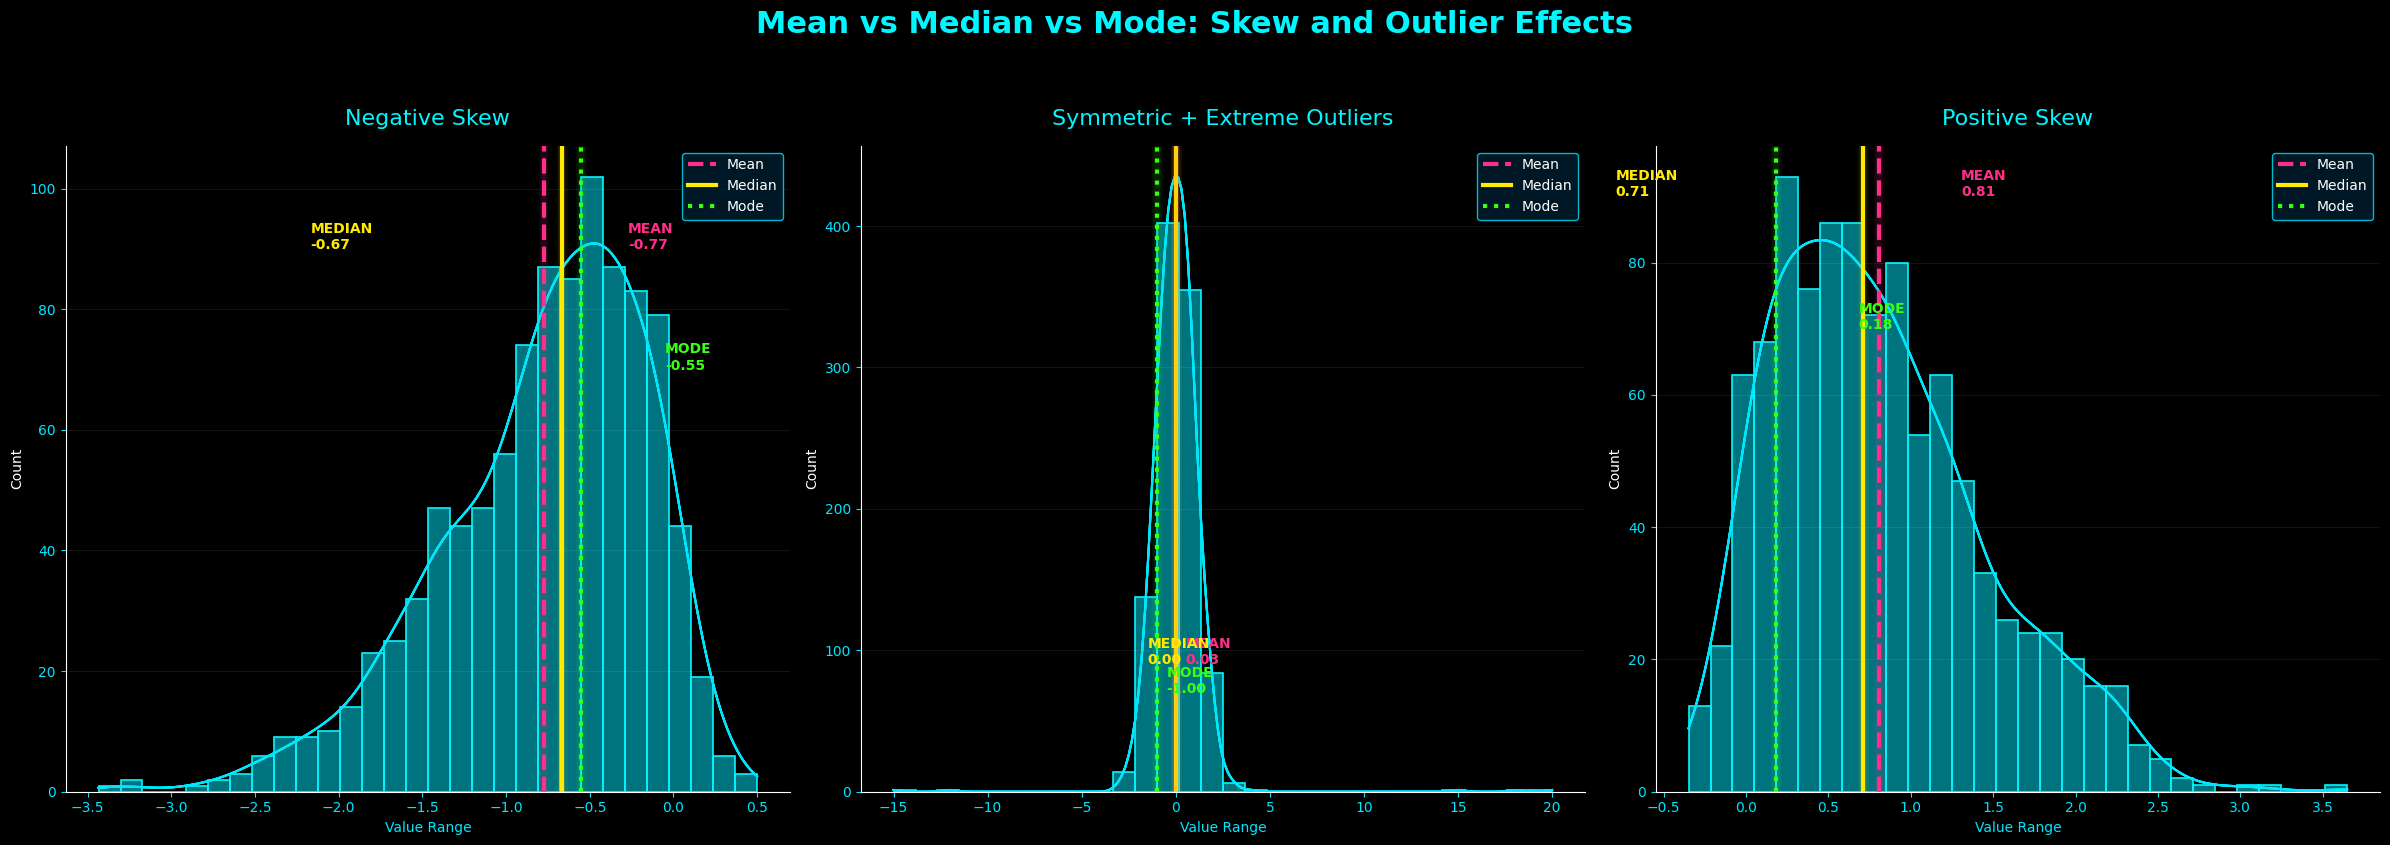

In [29]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skewnorm

np.random.seed(42)

# -----------------------------
# Generate Data
# -----------------------------
# Negative Skew
data_neg = skewnorm.rvs(-5, size=1000)

# Symmetric Data + Extreme Outliers
data_outlier = np.random.normal(0, 1, 1000)
data_outlier = np.append(data_outlier, [15, 18, 20, -15, -12])  # extreme outliers

# Positive Skew
data_pos = skewnorm.rvs(5, size=1000)

# -----------------------------
# Function to calculate stats
# -----------------------------
def calc_stats(data):
    mean_val = np.mean(data)
    median_val = np.median(data)
    # Approximate mode using histogram bin with max count
    hist, bins = np.histogram(data, bins=30)
    mode_val = bins[np.argmax(hist)]
    return mean_val, median_val, mode_val

neg_stats = calc_stats(data_neg)
out_stats = calc_stats(data_outlier)
pos_stats = calc_stats(data_pos)

# -----------------------------
# Plotting Setup
# -----------------------------
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle("Mean vs Median vs Mode: Skew and Outlier Effects",
             fontsize=22, color="#00f7ff", weight="bold", y=1.05)

# -----------------------------
# Function to plot each panel
# -----------------------------
def plot_glow_panel(ax, data, stats, title):
    mean_val, median_val, mode_val = stats

    # Glow histogram layers
    for alpha in [0.05, 0.08, 0.12]:
        sns.histplot(data, bins=30, kde=True, color="#00f7ff", alpha=alpha, linewidth=0, ax=ax)

    # Main histogram
    sns.histplot(data, bins=30, kde=True, color="#00e5ff", alpha=0.35,
                 edgecolor="#00f7ff", linewidth=1.2, ax=ax)

    # Lines for Mean, Median, Mode
    ax.axvline(mean_val, color="#ff2e88", linestyle="--", linewidth=3, label="Mean")
    ax.axvline(median_val, color="#ffea00", linestyle="-", linewidth=3, label="Median")
    ax.axvline(mode_val, color="#39ff14", linestyle=":", linewidth=3, label="Mode")

    # Glow effect for lines
    for lw in [8, 6, 4]:
        ax.axvline(mean_val, color="#ff2e88", alpha=0.05, linewidth=lw)
        ax.axvline(median_val, color="#ffea00", alpha=0.05, linewidth=lw)
        ax.axvline(mode_val, color="#39ff14", alpha=0.05, linewidth=lw)

    # Annotations
    ax.text(mean_val + 0.5, 90, f"MEAN\n{mean_val:.2f}", color="#ff2e88", weight="bold")
    ax.text(median_val - 1.5, 90, f"MEDIAN\n{median_val:.2f}", color="#ffea00", weight="bold")
    ax.text(mode_val + 0.5, 70, f"MODE\n{mode_val:.2f}", color="#39ff14", weight="bold")

    # Titles & labels
    ax.set_title(title, fontsize=16, color="#00f7ff", pad=15)
    ax.set_xlabel("Value Range", color="#00e5ff")
    ax.tick_params(colors="#00e5ff")
    ax.grid(axis="y", alpha=0.08)
    sns.despine(ax=ax)
    ax.legend(loc='upper right', frameon=True, edgecolor="#00e5ff", facecolor="#001f2f", labelcolor="white")

# -----------------------------
# Plot the three panels
# -----------------------------
plot_glow_panel(axes[0], data_neg, neg_stats, "Negative Skew")
plot_glow_panel(axes[1], data_outlier, out_stats, "Symmetric + Extreme Outliers")
plot_glow_panel(axes[2], data_pos, pos_stats, "Positive Skew")

plt.tight_layout()
plt.show()

The visualization above proves a fundamental rule of data preprocessing: The Mean is sensitive to extreme values, while the Median is robust.
-------------------------------------------------|
**Outlier Resistance (Panel 2):** In the central graph, we see a normal distribution tainted by five extreme outliers ($15, 18, 20, -15, -12$). The Mean (Pink) is heavily pulled toward these extremes, making it unrepresentative of the "typical" data point. The Median (Yellow), however, barely moves, staying at the true center of the bulk data.|
-------------------------------------------------|
**Maintaining Data Shape (Panels 1 & 3):** When data is skewed (not a perfect bell curve), the Mean is dragged toward the "tail" of the skew.
    - Negatively Skewed: Tail on the left pulls the mean down.
    - Positively Skewed: Tail on the right pulls the mean up.
---
**The Logic:** Using the Median ensures that missing values are filled with a number that actually reflects the majority of the data, preventing artificial distortions before model training.

--- ORIGINAL DATA STATISTICS ---
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

--- MEAN FILLED STATISTICS (Biased by Outliers) ---
count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: age, dtype: float64

--- MEDIAN FILLED STATISTICS (Robust) ---
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64


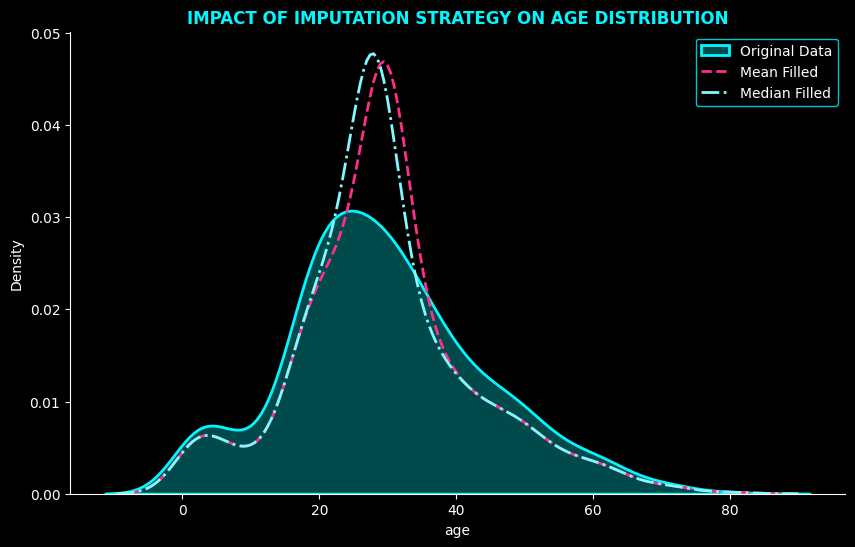

In [26]:
# @title
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = sns.load_dataset('titanic')

# 2. Focus on Age (which has missing values)
age_data = df['age'].dropna()

# 3. Simulate missing values by dropping them, then fill them back
#    Using Mean vs Using Median
age_with_nans = df['age'].copy()
mean_filled = age_with_nans.fillna(age_with_nans.mean())
median_filled = age_with_nans.fillna(age_with_nans.median())

# 4. Compare Statistics
print("--- ORIGINAL DATA STATISTICS ---")
print(age_data.describe())

print("\n--- MEAN FILLED STATISTICS (Biased by Outliers) ---")
print(mean_filled.describe())

print("\n--- MEDIAN FILLED STATISTICS (Robust) ---")
print(median_filled.describe())

# 5. Visualizing the Difference
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(age_data, color="#00f7ff", fill=True, alpha=0.3, label="Original Data", linewidth=2)
sns.kdeplot(mean_filled, color="#ff2e88", linestyle="--", label="Mean Filled", linewidth=2)
sns.kdeplot(median_filled, color="#7df9ff", linestyle="-.", label="Median Filled", linewidth=2)

ax.set_title("IMPACT OF IMPUTATION STRATEGY ON AGE DISTRIBUTION", color="#00f7ff", weight="bold")
ax.legend(edgecolor="#00f7ff")
sns.despine()
plt.show()

**2.  Explain in your own words what One-Hot Encoding does and why it is necessary.**

Machine Learning models require numerical data. One-Hot Encoding bridges this gap by converting text categories into binary numerical patterns, ensuring the algorithm treats them as unique categories without imposing an artificial numerical order or bias.

Each unique category gets its own column (like a separate switch).

Only one switch is active at a time, that is the column corresponding to the actual category as it gets a 1, and all others get 0.

This ensures the model sees no artificial ordering or bias between categories.

---
| Embarked | Embarked_C | Embarked_Q | Embarked_S |
|----------|------------|------------|------------|
| S        | 0          | 0          | 1          |
| C        | 1          | 0          | 0          |
| S        | 0          | 0          | 1          |
| S        | 0          | 0          | 1          |
| Q        | 0          | 1          | 0          |
---

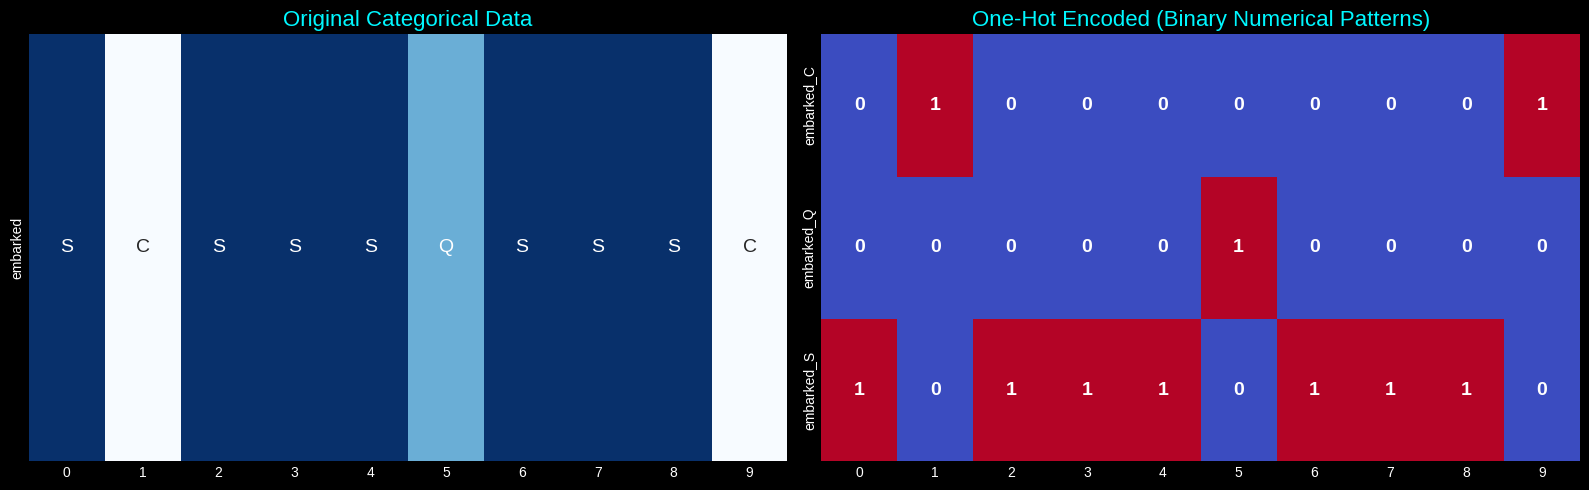

In [40]:
# @title
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = sns.load_dataset('titanic')

# 2. Select a categorical column to encode (e.g., 'embarked')
# Focus on the first 10 rows for a clear visual
df_cat = df[['embarked']].dropna().head(10)

# 3. Apply One-Hot Encoding (The bridge from text to binary numbers)
df_encoded = pd.get_dummies(df_cat, columns=['embarked'], dtype=int)

# 4. Visualization: Showing the conversion
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Original Categorical Data
sns.heatmap(df_cat.apply(lambda x: pd.Categorical(x).codes).T,
            annot=df_cat.T.values, fmt='', cbar=False,
            cmap="Blues", ax=axes[0], annot_kws={"size": 14})
axes[0].set_title("Original Categorical Data", fontsize=16, color="#00f7ff")

# Plot One-Hot Encoded Data (Numerical patterns)
sns.heatmap(df_encoded.T, annot=df_encoded.T.values, fmt='d', cbar=False,
            cmap="coolwarm", ax=axes[1], annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("One-Hot Encoded (Binary Numerical Patterns)", fontsize=16, color="#00f7ff")

plt.tight_layout()
plt.show()

**Original Data**: Shows the text categories.

**One-Hot Encoded Data**: Shows the “binary switches” that the machine can process.

|The heatmap visual you see matches this logic:|
----------------------------------------------|
- The left panel shows the original categories.
- The right panel shows the binary patterns, highlighting how each category is encoded numerically.

This method allows models to learn from categorical data without introducing artificial relationships, giving each category equal importance.

3.**Do we need to scale features for a Decision Tree?**  
No. Decision Trees only check if feature values are greater or smaller than certain thresholds, so changing the scale of the data does not affect how the tree splits or makes decisions.

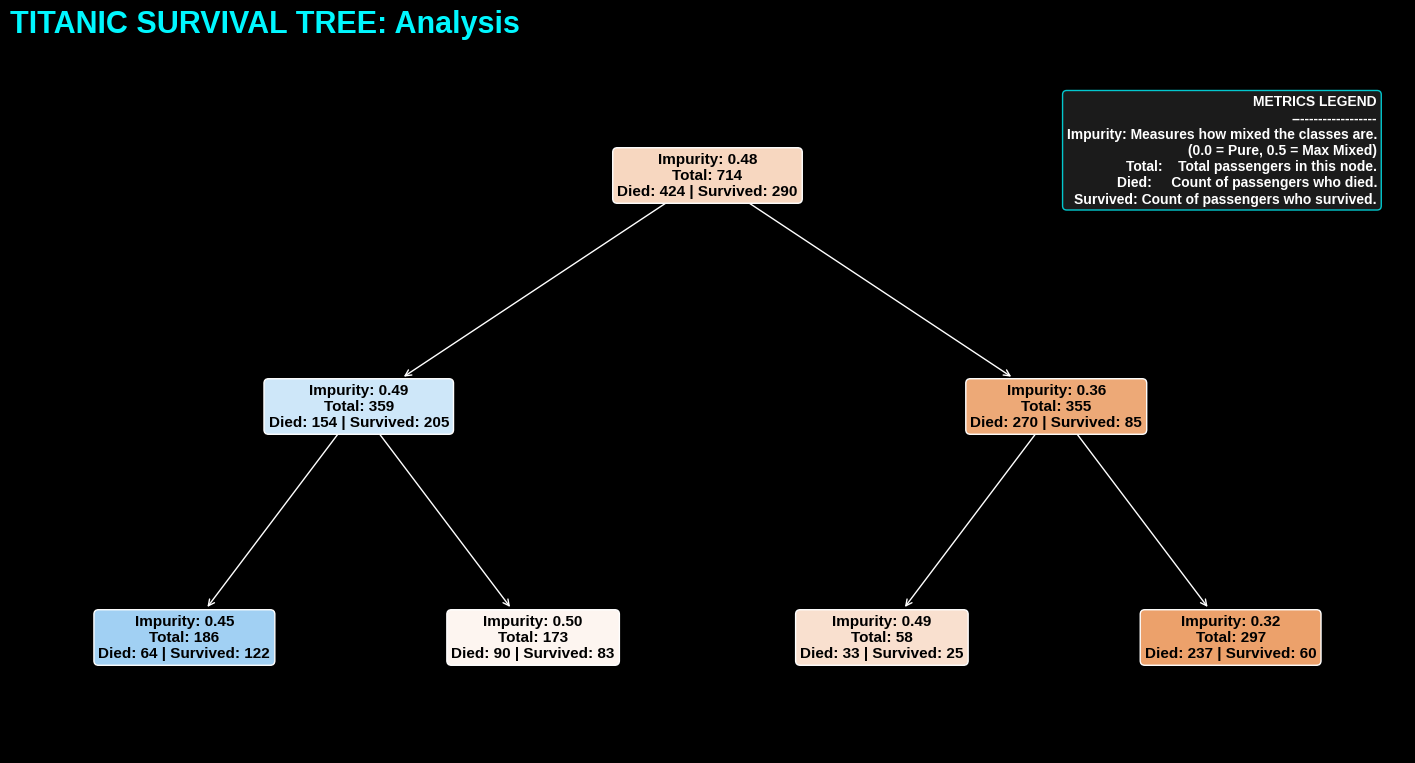

In [56]:
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

# 1. Load and Clean Dataset
df = sns.load_dataset('titanic')
df_clean = df[['survived', 'age', 'pclass']].dropna()

X = df_clean[['age', 'pclass']]
y = df_clean['survived']

# 2. Train a simple tree
tree_model = DecisionTreeClassifier(max_depth=2, min_samples_leaf=50)
tree_model.fit(X, y)

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(18, 9))

# Plot the tree
text_annotations = plot_tree(tree_model,
                             feature_names=['Age', 'Pclass'],
                             class_names=['Died', 'Survived'],
                             filled=True,
                             rounded=True,
                             fontsize=11,
                             ax=ax)

# --- LOGIC: SIMPLIFY AND INCREASE CONTRAST ---
for text_obj in text_annotations:
    text_content = text_obj.get_text()

    # Update text color for readability
    text_obj.set_color("black")
    text_obj.set_weight("bold")

    if 'value' in text_content:
        # Extract numerical data using regular expressions
        gini_match = re.search(r'gini = ([\d.]+)', text_content)
        samples_match = re.search(r'samples = (\d+)', text_content)
        value_match = re.search(r'value = \[(\d+), (\d+)\]', text_content)

        # Parse data
        gini = float(gini_match.group(1))
        samples = int(samples_match.group(1))
        died = int(value_match.group(1))
        survived = int(value_match.group(2))

        # Create a new, simple label
        new_label = (
            f"Impurity: {gini:.2f}\n"
            f"Total: {samples}\n"
            f"Died: {died} | Survived: {survived}"
        )

        # Update the node text
        text_obj.set_text(new_label)

# --- NEW LOGIC: ADD CUSTOM LEGEND TABLE ---
legend_text = (
    "METRICS LEGEND\n"
    "-------------------\n"
    "Impurity: Measures how mixed the classes are.\n"
    "         (0.0 = Pure, 0.5 = Max Mixed)\n"
    "Total:    Total passengers in this node.\n"
    "Died:     Count of passengers who died.\n"
    "Survived: Count of passengers who survived."
)

# Place the legend in the top right
props = dict(boxstyle='round', facecolor='#222222', alpha=0.8, edgecolor='#00f7ff')
ax.text(0.98, 0.95, legend_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props, color="white", weight="bold")

# Final styling for title
ax.set_title("TITANIC SURVIVAL TREE: Analysis",
          color="#00f7ff", fontsize=22, weight="bold", pad=20, loc="left")
plt.show()

This **Decision Tree** predicts Titanic survival using Age and Pclass.

**Nodes**: Split based on feature thresholds (e.g., Age ≤ 28, Pclass ≤ 2).

**Labels**: Show Impurity (0 = pure, 0.5 = mixed), Total passengers, and counts of Died / Survived.

**Leaves**: Indicate the final survival decision for passengers in that node.


| Splits rely on raw thresholds, so scaling:
|---

**Age** \
        or\
**Pclass**\
   does **NOT** change the tree’s logic.

---
**Decision Trees** only care whether values are above or below thresholds, not their absolute magnitude.
